In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For propensity score matching and survival analysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from lifelines import CoxPHFitter, KaplanMeierFitter

In [2]:
conn = duckdb.connect(database='/workspaces/txwc/tx_workers_comp.db', read_only=False)

In [3]:
surgical_query = """
SELECT po.person_id,
       po.procedure_occurrence_id,
       po.procedure_date,
       cr.concept_id_2 AS surgical_indicator
FROM tx_workers_comp.omop.concept_relationship cr
JOIN tx_workers_comp.omop.procedure_occurrence po 
  ON po.procedure_concept_id = cr.concept_id_1
WHERE cr.relationship_id = 'Has method'
  AND cr.concept_id_2 = '4045049' -- Surgical Action
"""
surgical_df = conn.execute(surgical_query).fetchdf()

# Mark these patients as receiving surgery
surgical_df['treatment'] = 1

surgical_df.head()

,person_id,procedure_occurrence_id,procedure_date,surgical_indicator,treatment
0,398572253,491529,2013-05-24,4045049,1
1,681781086,491584,2012-12-21,4045049,1
2,Q92X0V989HX,491705,2023-07-19,4045049,1
3,P4ARVTPK5G,491752,2010-05-27,4045049,1
4,NA2JC9CAYCEG2,491880,2010-01-04,4045049,1


In [4]:
no_surgery_query = """
SELECT co.person_id,
       co.condition_occurrence_id,
       co.condition_start_date AS injury_date
FROM tx_workers_comp.omop.condition_occurrence co
JOIN tx_workers_comp.omop.concept c 
  ON co.condition_concept_id = c.concept_id
"""
no_surgery_df = conn.execute(no_surgery_query).fetchdf()

# Exclude patients already in the surgical cohort
conservative_df = no_surgery_df[~no_surgery_df['person_id'].isin(surgical_df['person_id'])]

# Mark these patients as conservative management
conservative_df['treatment'] = 0

conservative_df.head()

/tmp/ipykernel_16629/3416524910.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  conservative_df['treatment'] = 0


,person_id,condition_occurrence_id,injury_date,treatment
0,RVA00QR0PJ,614401,2013-01-01,0
1,824030956,614402,2011-07-03,0
2,792558078,614403,NaT,0
3,293246853,614404,2010-10-04,0
4,CJJC5JP80X,614405,2022-01-06,0


In [5]:
person_query = """
SELECT person_id,
       gender_concept_id,
       year_of_birth
FROM tx_workers_comp.omop.person p
"""
person_df = conn.execute(person_query).fetchdf()

person_df.head()

,person_id,gender_concept_id,year_of_birth
0,LXLL89TLLDSXIXIM98,8532,1977
1,8CA856V818OOY,8507,1985
2,6VLE3LDDF0VLVM5DVM,8507,2003
3,W1W78XX7Y66X1I,8507,1974
4,612436212,8532,1982


In [6]:
gender_mapping = {
    '8507': 'MALE',
    '8532': 'FEMALE'
}

# Merge surgical_df with person_df to add demographic information
surgical_df = surgical_df.merge(
    person_df[['person_id', 'gender_concept_id', 'year_of_birth']],
    on='person_id',
    how='left'
)

# Convert procedure_date to datetime and compute age at injury
surgical_df['index_date'] = pd.to_datetime(surgical_df['procedure_date'])
surgical_df['age_at_injury'] = surgical_df['index_date'].dt.year - surgical_df['year_of_birth']

# Map gender codes to string labels (if desired)
surgical_df['gender'] = surgical_df['gender_concept_id'].map(gender_mapping)

# Select only the common columns you want to work with
surgical_df = surgical_df[['person_id', 'treatment', 'index_date', 'age_at_injury', 'gender']]

In [7]:
conservative_df = conservative_df.merge(
    person_df[['person_id', 'gender_concept_id', 'year_of_birth']],
    on='person_id',
    how='left'
)

conservative_df['index_date'] = pd.to_datetime(conservative_df['injury_date'])

conservative_df['age_at_injury'] = conservative_df['index_date'].dt.year - conservative_df['year_of_birth']

# Map gender codes to string labels using the appropriate gender column.
conservative_df['gender'] = conservative_df['gender_concept_id'].map(gender_mapping)

# Select only the common columns
conservative_df = conservative_df[['person_id', 'treatment', 'index_date', 'age_at_injury', 'gender']]

In [8]:
# Combine cohorts
df_cohorts = pd.concat([surgical_df, conservative_df], ignore_index=True)

In [12]:
# Map gender to a binary variable: FEMALE -> 0, MALE -> 1
df_cohorts['gender_encoded'] = df_cohorts['gender'].map({'FEMALE': 0, 'MALE': 1})

/tmp/ipykernel_16629/70512981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cohorts['gender_encoded'] = df_cohorts['gender'].map({'FEMALE': 0, 'MALE': 1})


In [13]:
covariates = ['age_at_injury', 'gender_encoded']
df_cohorts = df_cohorts.dropna(subset=covariates)

In [14]:
# Fit logistic regression to estimate the propensity score for receiving surgery
ps_model = LogisticRegression()
X = df_cohorts[covariates]
y = df_cohorts['treatment']
ps_model.fit(X, y)
df_cohorts['propensity_score'] = ps_model.predict_proba(X)[:, 1]

In [15]:
# Perform 1:1 nearest neighbor matching (without replacement) on the propensity score.
# Separate the groups.
surgical = df_cohorts[df_cohorts['treatment'] == 1].copy()
conservative = df_cohorts[df_cohorts['treatment'] == 0].copy()

In [16]:
# Use NearestNeighbors to find the closest match in the conservative group for each surgical patient.
nn = NearestNeighbors(n_neighbors=1)
nn.fit(conservative[['propensity_score']])
distances, indices = nn.kneighbors(surgical[['propensity_score']])
matched_conservative = conservative.iloc[indices.flatten()].copy()

# Align indices so we can combine surgical and matched conservative patients.
matched_conservative.index = surgical.index

In [17]:
# Create the matched dataset
matched_df = pd.concat([surgical, matched_conservative], axis=0).reset_index(drop=True)

In [18]:
# Outcome Definition and Survival Analysis
np.random.seed(42)
matched_df['time_to_return_to_work'] = np.random.exponential(scale=100, size=len(matched_df)).astype(int)
matched_df['event'] = np.random.binomial(1, 0.7, size=len(matched_df))

In [19]:
# Fit a Cox Proportional Hazards model.
cph = CoxPHFitter()
# Include treatment and the matching covariates in the model.
model_cols = ['time_to_return_to_work', 'event', 'treatment'] + covariates
cph.fit(matched_df[model_cols], duration_col='time_to_return_to_work', event_col='event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 145672 total observations, 43806 right-censored observations>
             duration col = 'time_to_return_to_work'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 145672
number of events observed = 101866
   partial log-likelihood = -1109490.24
         time fit was run = 2025-04-02 03:37:24 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
treatment       0.00      1.00      0.01           -0.01            0.01                0.99                1.01
age_at_injury  -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
gender_encoded  0.00      1.00      0.01           -0.01            0.02                0.99                1.02

                cmp to     z    p  -log2(p)
covariate                                  
treatment         0.00  0.26 0.79      0.33
age_at_injury     0.00 -2.79 0.01      7.55
gender_encoded    0.00  0.47 0.64      0.65
---
Concordance = 0.50
Partial AIC = 2218986.47
log-likelihood ratio test = 8.18 on 3 df
-log2(p) of ll-ratio test = 4.56

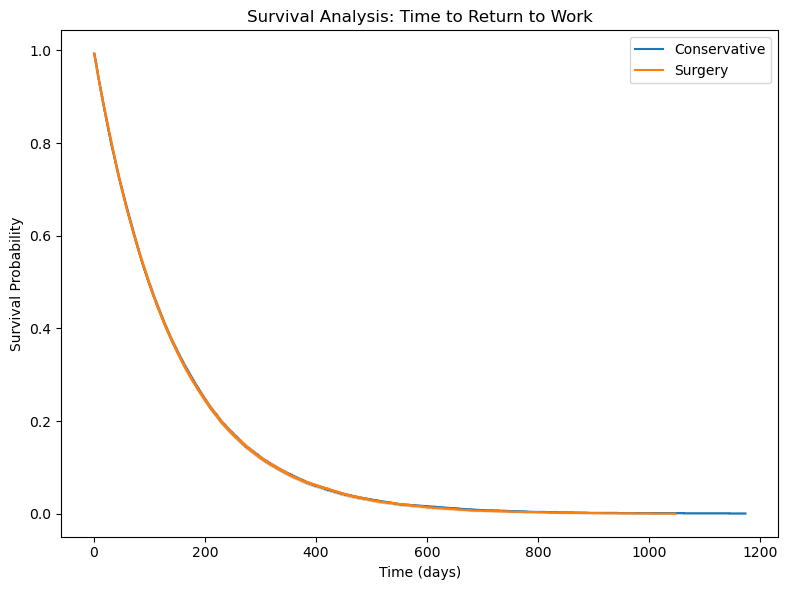

In [20]:
# Plot Kaplan–Meier survival curves by treatment group.
kmf = KaplanMeierFitter()

plt.figure(figsize=(8, 6))
for label, grouped_df in matched_df.groupby('treatment'):
    kmf.fit(durations=grouped_df['time_to_return_to_work'],
            event_observed=grouped_df['event'],
            label='Surgery' if label == 1 else 'Conservative')
    kmf.plot_survival_function(ci_show=True)
plt.title("Survival Analysis: Time to Return to Work")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.show()

In [ ]:
conn.close()